# Relatório de Processamento de Imagens com Filtros Passa-Baixa

**Autores:** Fabricio da costa Fernandes (RA 11202321635), Felipe de Lima Major (RA 11202230321), Lilian Gimenez Teixeira (RA 11202332321)

**Data dos experimentos:** 11/03/2026

**Data de publicação:** 17/03/2026

## Introdução

Este relatório apresenta a aplicação de técnicas de filtragem espacial em imagens digitais, com o objetivo de identificar bordas e destacar características relevantes.

A filtragem espacial consiste na aplicação de operadores matemáticos diretamente sobre os pixels da imagem, permitindo realçar detalhes, detectar contornos e reduzir ruídos.

Neste experimento, foram utilizados os seguintes métodos:
- Conversão para escala de cinza
- Filtro Laplaciano
- Filtros de Sobel
- Detector de bordas de Canny

As análises foram realizadas utilizando Python e bibliotecas como OpenCV e Matplotlib.

### Leitura das imagens

As imagens foram carregadas utilizando a biblioteca OpenCV e convertidas do padrão BGR para RGB para correta visualização.

In [10]:
import cv2
import matplotlib.pyplot as plt

def read_image(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

def show_image(img, title=""):
    plt.figure(figsize=(6,6))
    plt.imshow(img, cmap="gray")
    plt.title(title)
    plt.axis("off")

foto_grupo = read_image("static/foto-grupo.jpg")
avatar = read_image("static/avatares.jpg")

### Conversão para escala de cinza

A conversão para tons de cinza reduz a complexidade da imagem, facilitando a aplicação de operadores de detecção de bordas.

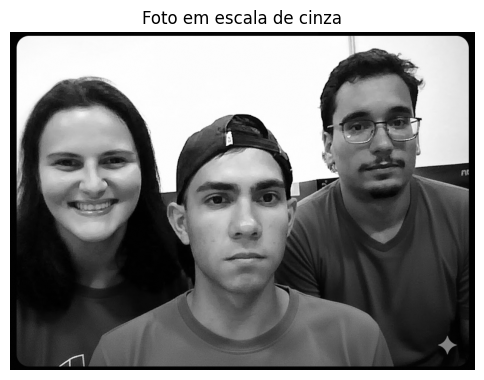

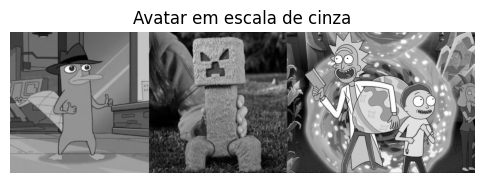

In [11]:
foto_gray = cv2.cvtColor(foto_grupo, cv2.COLOR_RGB2GRAY)
avatar_gray = cv2.cvtColor(avatar, cv2.COLOR_RGB2GRAY)

show_image(foto_gray, "Foto em escala de cinza")
show_image(avatar_gray, "Avatar em escala de cinza")

### Filtro Laplaciano

O operador Laplaciano é utilizado para detectar regiões de rápida variação de intensidade, sendo eficaz na identificação de bordas.

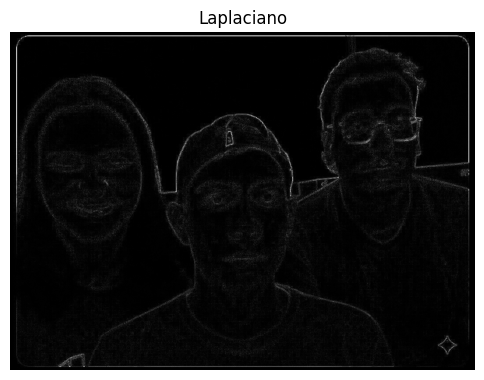

In [12]:
import numpy as np

lap_foto = cv2.Laplacian(foto_gray, cv2.CV_64F)
lap_foto = np.uint8(np.absolute(lap_foto))

show_image(lap_foto, "Laplaciano")

### Filtro de Sobel

O operador de Sobel calcula o gradiente da imagem nas direções horizontal (x) e vertical (y), permitindo identificar bordas em diferentes orientações.

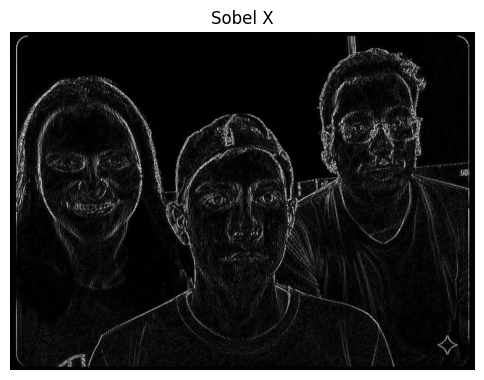

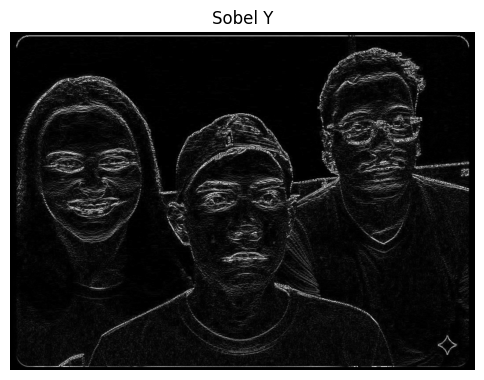

In [13]:
sobelx = cv2.Sobel(foto_gray, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(foto_gray, cv2.CV_64F, 0, 1, ksize=3)

sobelx = np.uint8(np.absolute(sobelx))
sobely = np.uint8(np.absolute(sobely))

show_image(sobelx, "Sobel X")
show_image(sobely, "Sobel Y")

### Detector de bordas de Canny

O algoritmo de Canny é um dos métodos mais eficientes para detecção de bordas, pois considera múltiplas etapas como redução de ruído, cálculo de gradiente e limiarização.

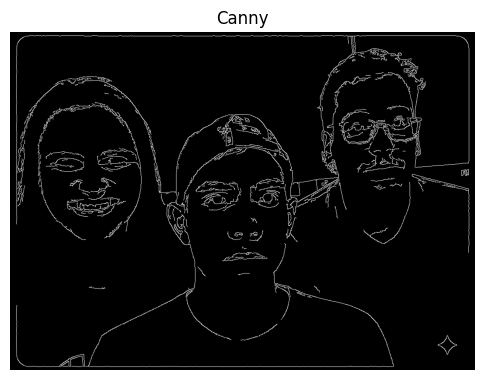

In [14]:
canny = cv2.Canny(foto_gray, 100, 200)

show_image(canny, "Canny")

## Análise e Discussão

A aplicação dos diferentes filtros permitiu observar comportamentos distintos:

- O filtro Laplaciano destacou bordas de forma mais sensível, porém com maior presença de ruído.
- O operador de Sobel apresentou melhor controle direcional, evidenciando bordas horizontais e verticais separadamente.
- O método de Canny produziu resultados mais refinados, com bordas mais definidas e menor interferência de ruído.

Além disso, foi possível observar que a escolha dos parâmetros (como tamanho do kernel e limiares) impacta diretamente na qualidade da detecção de bordas.

## Realce de Imagens com Laplaciano e Highboost

Nesta etapa, foram aplicadas técnicas de realce de imagens com o objetivo de destacar detalhes e melhorar a nitidez.

Foram utilizados:
- Filtro Laplaciano (realce de bordas)
- Técnica de Highboost (realce geral da imagem)

Essas técnicas são amplamente utilizadas em processamento de imagens para melhorar a qualidade visual e evidenciar detalhes importantes.

### Filtro Laplaciano para realce

O filtro Laplaciano destaca regiões de variação intensa de intensidade, sendo útil para evidenciar detalhes finos e bordas.

Para realce, o resultado do Laplaciano pode ser combinado com a imagem original.

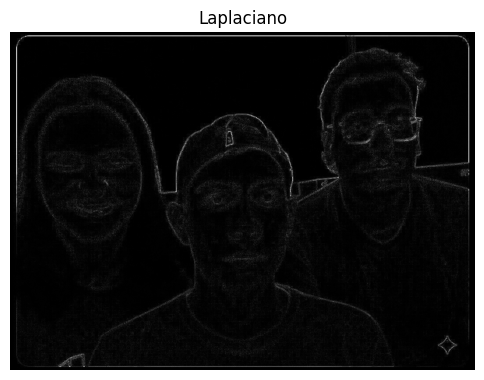

In [15]:
lap = cv2.Laplacian(foto_gray, cv2.CV_64F)
lap = np.uint8(np.absolute(lap))

show_image(lap, "Laplaciano")

### Realce utilizando Laplaciano

O realce pode ser obtido somando a imagem original com o negativo do Laplaciano, aumentando o contraste das bordas.

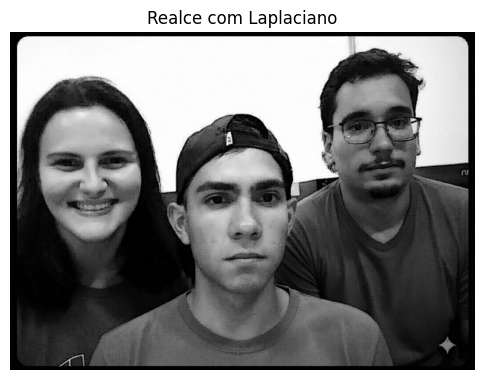

In [16]:
sharp_lap = cv2.subtract(foto_gray, lap)

show_image(sharp_lap, "Realce com Laplaciano")

### Filtro Highboost

O filtro Highboost é uma técnica de realce que amplifica os detalhes da imagem original.

Ele é baseado na seguinte ideia:
- Subtrair uma versão borrada da imagem (máscara)
- Somar essa diferença de volta à imagem original com um fator de amplificação

Fórmula:
Highboost = Imagem original + k * (Imagem original - Imagem borrada)

Onde:
- k > 1 aumenta o nível de realce

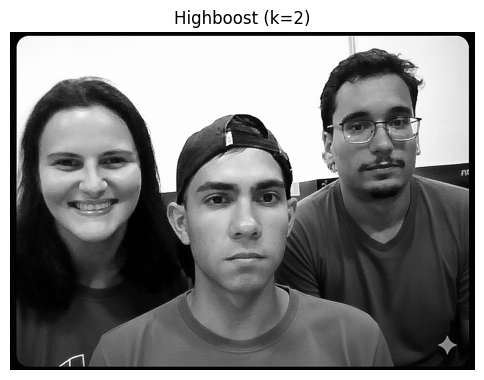

In [17]:
# Suavização (blur)
blur = cv2.GaussianBlur(foto_gray, (5,5), 0)

# Máscara (detalhes)
mask = cv2.subtract(foto_gray, blur)

# Fator de amplificação
k = 2

# Highboost
highboost = cv2.add(foto_gray, k * mask)

show_image(highboost, "Highboost (k=2)")

## Análise e Discussão

Os resultados mostram diferenças claras entre as técnicas:

- O Laplaciano destaca fortemente as bordas, mas pode introduzir ruído.
- O realce com Laplaciano melhora a nitidez, porém de forma mais agressiva.
- O Highboost permite controle do nível de realce através do parâmetro k, sendo mais flexível.

Observou-se que valores maiores de k aumentam o contraste dos detalhes, mas também podem amplificar ruídos indesejados.

Dessa forma, o Highboost se mostrou uma técnica mais ajustável e adequada para diferentes cenários.

## Conclusão

Os experimentos demonstraram a importância da filtragem espacial no processamento de imagens digitais.

Cada técnica apresentou vantagens específicas:
- Laplaciano: maior sensibilidade
- Sobel: análise direcional
- Canny: melhor qualidade geral

Além disso, as as de realce como Laplaciano e Highboost demonstraram ser eficazes para melhorar a qualidade visual das imagens.

O método Highboost se destacou pela sua flexibilidade, permitindo ajustar o nível de realce conforme a necessidade.

Conclui-se que a escolha do método depende do objetivo da aplicação, sendo o detector de Canny o mais indicado para identificação precisa de bordas. 

## Referências

- OpenCV Documentation: https://opencv.org/
- Gonzalez, R. C.; Woods, R. E. – Processamento Digital de Imagens
- Documentação do Matplotlib